In [1]:
# data_exploration.ipynb

# Setup
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# modeling used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss
import xgboost as xgb

# Display settings
pd.set_option('display.max_columns', None)


In [2]:
# Load Dataset
df = pd.read_csv("../data/raw/all_teams2.csv")
print("Shape:", df.shape)
df.head()

Shape: (222330, 111)


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame
0,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,other,0.0000,0.0000,0.0000,42.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.689,0.019,0.069,0.164,0.020,0.521,0.207,0.019,0.019,0.019,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.019,0.000,0.000,0.0,0.0,0.0,1.00,1.0,1.000,0.0,0.017,0.000,0.000,0.037,0.037,0.037,0
1,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,all,0.4596,0.6408,0.6310,3600.0,37.733,2.287,2.842,8.155,1.134,22.530,16.054,2.249,2.396,2.357,41.0,12.0,13.0,66.0,2.0,1.0,0.0,14.0,2.0,18.0,16.0,39.0,51.0,4.0,8.0,30.0,16.0,19.0,8.0,44.0,8.0,1.0,1.040,0.811,0.435,1.0,0.0,1.0,68.292,53.0,54.697,4.0,0.641,0.014,0.029,2.899,3.030,2.980,22.880,2.689,1.780,4.436,0.639,12.626,8.830,2.524,2.607,2.450,21.0,10.0,6.0,37.0,1.0,1.0,0.0,5.0,1.0,8.0,15.0,20.0,30.0,7.0,14.0,32.0,17.0,11.0,7.0,16.0,12.0,3.0,0.599,1.278,0.811,1.0,0.0,0.0,36.14,31.0,30.369,5.0,0.396,0.168,0.168,2.917,2.833,2.714,0
2,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,5on5,0.4857,0.6429,0.6364,2283.0,24.802,1.693,1.724,5.513,0.739,14.650,10.681,1.656,1.803,1.764,28.0,7.0,10.0,45.0,1.0,0.0,0.0,10.0,1.0,14.0,9.0,27.0,34.0,3.0,6.0,19.0,13.0,13.0,7.0,27.0,8.0,0.0,0.882,0.811,0.000,1.0,0.0,0.0,47.292,35.0,36.697,4.0,0.355,0.000,0.000,2.048,2.180,2.130,14.729,1.793,1.117,3.001,0.406,7.737,5.946,1.633,1.711,1.559,11.0,9.0,5.0,25.0,1.0,1.0,0.0,4.0,1.0,4.0,9.0,10.0,19.0,7.0,14.0,18.0,13.0,9.0,5.0,12.0,6.0,2.0,0.498,0.689,0.606,1.0,0.0,0.0,24.14,20.0,19.369

In [3]:
# Explore Columns
df.info()
df.describe().T.head(10)

# check sample columns
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222330 entries, 0 to 222329
Columns: 111 entries, team to playoffGame
dtypes: float64(100), int64(4), object(7)
memory usage: 188.3+ MB


['team',
 'season',
 'name',
 'gameId',
 'playerTeam',
 'opposingTeam',
 'home_or_away',
 'gameDate',
 'position',
 'situation',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'iceTime',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 '

In [4]:
# Feature Engineering

# Target variable: 1 = Win, 0 = Loss
df['win'] = (df['goalsFor'] > df['goalsAgainst']).astype(int)

# Merge Arizona with Utah due to the team relocation
df['team'] = df['team'].replace({'ARI': 'UTA'})

# Filter to keep only seasons from 2022 onward
df_recent = df[df['season'] >= 2022].reset_index(drop=True)
print("Filtered recent seasons (>= 2022):", len(df_recent))
print("Unique seasons:", df_recent['season'].unique())

# From the recent data, select only rows where situation == 'all'
df_all = df_recent[df_recent['situation'] == 'all'].reset_index(drop=True)
print("\nRows with situation == 'all':", len(df_all))
print("Unique games before cleanup:", df_all['gameId'].nunique())

# Detect and remove bad games, each game should have exactly one winner
game_win_sums = df_all.groupby('gameId')['win'].sum()

# Identify invalid games
bad_game_ids = game_win_sums[game_win_sums != 1].index
print("Bad games detected:", len(bad_game_ids))

# Remove invalid games
df_all = df_all[~df_all['gameId'].isin(bad_game_ids)].reset_index(drop=True)

# Print cleanup summary
print("\n✅ After cleanup:")
print("Total rows:", len(df_all))
print("Unique games:", df_all['gameId'].nunique())
print("Win counts:\n", df_all['win'].value_counts())

# Create performance difference features
df_all['shot_diff'] = df_all['shotsOnGoalFor'] - df_all['shotsOnGoalAgainst']
df_all['penalty_diff'] = df_all['penaltiesFor'] - df_all['penaltiesAgainst']
df_all['shotAttempt_diff'] = df_all['shotAttemptsFor'] - df_all['shotAttemptsAgainst']
df_all['faceOff_diff'] = df_all['faceOffsWonFor'] - df_all['faceOffsWonAgainst']


# Export cleaned DataFrames to ../data/processed/
df_recent.to_csv('../data/processed/recent_teams.csv', index=False)
df_all.to_csv('../data/processed/processed_teams.csv', index=False)

print("\n Saved both files to ../data/processed/:")
print(" - recent_teams.csv  → all data since 2022")
print(" - processed_teams.csv → cleaned + situation == 'all'")

# Preview cleaned data
df_all.head()


Filtered recent seasons (>= 2022): 46030
Unique seasons: [2022 2023 2024 2025]

Rows with situation == 'all': 9206
Unique games before cleanup: 4603
Bad games detected: 292

✅ After cleanup:
Total rows: 8622
Unique games: 4311
Win counts:
 win
1    4311
0    4311
Name: count, dtype: int64

 Saved both files to ../data/processed/:
 - recent_teams.csv  → all data since 2022
 - processed_teams.csv → cleaned + situation == 'all'


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff
0,NYR,2022,NYR,2022020003,NYR,TBL,HOME,20221011,Team Level,all,0.6699,0.6068,0.5904,3600.0,36.626,5.589,3.084,7.843,1.190,18.568,12.727,4.959,5.524,4.897,39.0,10.0,22.0,71.0,3.0,6.0,0.0,2.0,3.0,24.0,11.0,36.0,46.0,6.0,12.0,30.0,24.0,19.0,17.0,26.0,14.0,9.0,1.008,1.556,3.025,1.0,2.0,0.0,70.854,49.0,48.988,5.0,0.688,1.358,1.358,4.919,4.868,4.578,25.294,2.754,1.868,5.870,1.073,14.067,8.368,2.446,2.813,2.504,26.0,8.0,12.0,46.0,1.0,2.0,0.0,6.0,0.0,10.0,15.0,25.0,33.0,4.0,8.0,17.0,19.0,8.0,15.0,24.0,6.0,4.0,0.635,0.757,1.362,0.0,0.0,1.0,46.551,34.0,34.315,5.0,0.465,0.176,0.176,3.043,3.102,2.754,0,1,13.0,2.0,25.0,13.0
1,NYR,2022,NYR,2022020017,NYR,MIN,AWAY,20221013,Team Level,all,0.4152,0.4655,0.4556,3600.0,30.783,3.165,2.387,7.092,0.930,16.263,11.163,3.123,3.400,3.356,35.0,6.0,13.0,54.0,7.0,4.0,1.0,6.0,0.0,10.0,14.0,28.0,34.0,7.0,17.0,29.0,27.0,4.0,1.0,29.0,9.0,3.0,0.641,1.088,1.436,1.0,3.0,3.0,61.002,41.0,45.018,0.0,0.536,0.336,0.336,3.365,3.596,3.554,35.567,4.457,2.568,7.138,1.252,18.462,15.123,3.833,4.294,3.670,36.0,13.0,13.0,62.0,3.0,3.0,0.0,5.0,0.0,18.0,20.0,33.0,46.0,8.0,19.0,29.0,20.0,9.0,6.0,30.0,13.0,6.0,1.092,1.703,1.662,0.0,2.0,1.0,57.921,49.0,46.481,2.0,0.626,0.954,0.954,4.128,3.953,3.584,0,1,-1.0,-1.0,-8.0,0.0
2,NYR,2022,NYR,2022020023,NYR,WPG,AWAY,20221014,Team Level,all,0.4000,0.5185,0.5481,3600.0,40.542,2.814,2.906,9.682,1.407,23.631,16.561,2.725,2.863,2.773,41.0,16.0,13.0,70.0,1.0,6.0,0.0,7.0,2.0,21.0,20.0,40.0,56.0,3.0,6.0,28.0,25.0,3.0,20.0,46.0,10.0,1.0,1.318,1.288,0.208,1.0,0.0,0.0,69.733,57.0,56.422,18.0,0.645,0.430,0.430,3.029,3.073,2.982,33.758,4.221,2.192,7.402,1.079,18.976,13.131,4.109,4.173,4.062,3

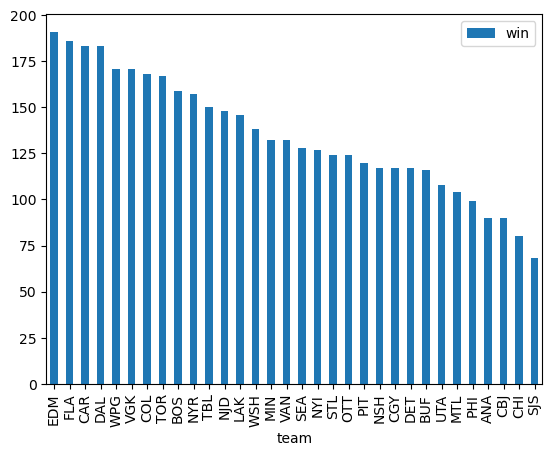

In [5]:
# Visualizations
df_grouped = df_all.groupby('team')['win'].sum().reset_index().sort_values(by='win', ascending=False)

df_grouped.plot.bar(x='team', y='win')
plt.show()

Wins: 4311, Losses: 4311


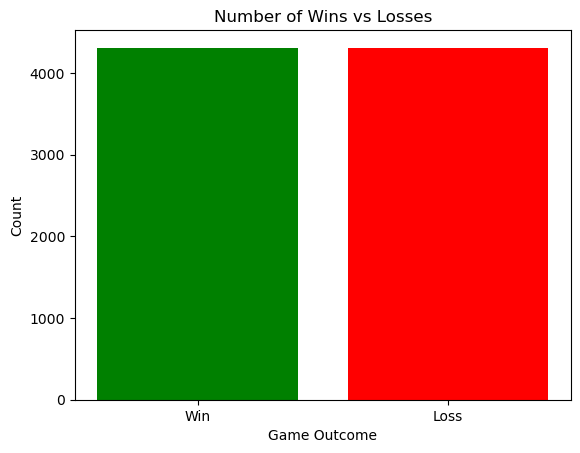

In [6]:
# Exploratory Analysis

# Count wins and losses
win_count = (df_all['win'] == 1).astype(int).sum()
loss_count = (df_all['win'] == 0).astype(int).sum()
print(f"Wins: {win_count}, Losses: {loss_count}")

# Values
categories = ['Win', 'Loss']
counts = [win_count, loss_count]

# Plot
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Number of Wins vs Losses')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

In [7]:
#Final sanity checks

# Check unique teams in recent data
current_teams = df_all['team'].unique()
print("Number of unique teams:", len(current_teams))
print("Teams:", sorted(current_teams))

# Display win counts per team
print(df_all.groupby('team')['win'].agg(['sum', 'count']))

# Check for any NaN values in recent data
print("Any NaNs?", df_all.isna().sum().sum())

# Check for duplicated game-team entries in cleaned data
dup_games = df_all[df_all.duplicated(['gameId', 'team'])]
print("Duplicated rows:", len(dup_games))

Number of unique teams: 32
Teams: ['ANA', 'BOS', 'BUF', 'CAR', 'CBJ', 'CGY', 'CHI', 'COL', 'DAL', 'DET', 'EDM', 'FLA', 'LAK', 'MIN', 'MTL', 'NJD', 'NSH', 'NYI', 'NYR', 'OTT', 'PHI', 'PIT', 'SEA', 'SJS', 'STL', 'TBL', 'TOR', 'UTA', 'VAN', 'VGK', 'WPG', 'WSH']
      sum  count
team            
ANA    90    254
BOS   159    276
BUF   116    254
CAR   183    293
CBJ    90    253
CGY   117    251
CHI    80    258
COL   168    273
DAL   183    307
DET   117    255
EDM   191    321
FLA   186    322
LAK   146    262
MIN   132    255
MTL   104    248
NJD   148    274
NSH   117    263
NYI   127    262
NYR   157    280
OTT   124    263
PHI    99    246
PIT   120    253
SEA   128    265
SJS    68    250
STL   124    258
TBL   150    273
TOR   167    289
UTA   108    258
VAN   132    268
VGK   171    288
WPG   171    286
WSH   138    264
Any NaNs? 0
Duplicated rows: 0


<Axes: >

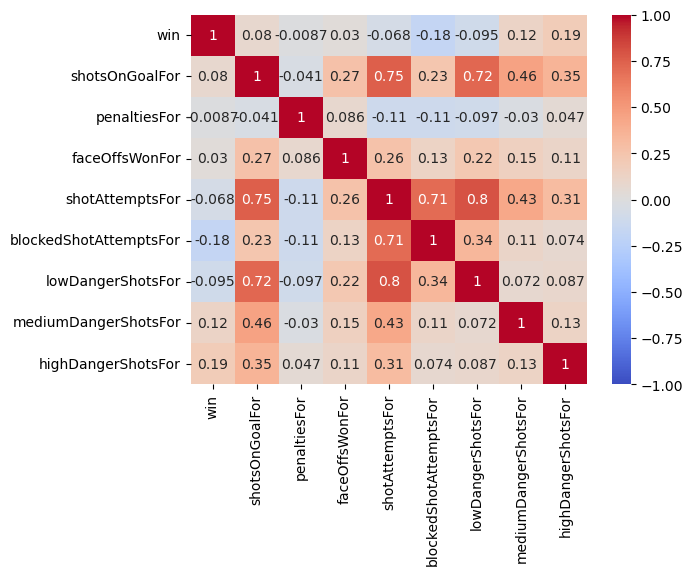

In [8]:
# Correlation heat maps
corr = df_all[['win','shotsOnGoalFor','penaltiesFor', 'faceOffsWonFor', 'shotAttemptsFor', 'blockedShotAttemptsFor', 'lowDangerShotsFor', 'mediumDangerShotsFor', 'highDangerShotsFor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

Text(0.5, 0, 'faceOffsWonFor')

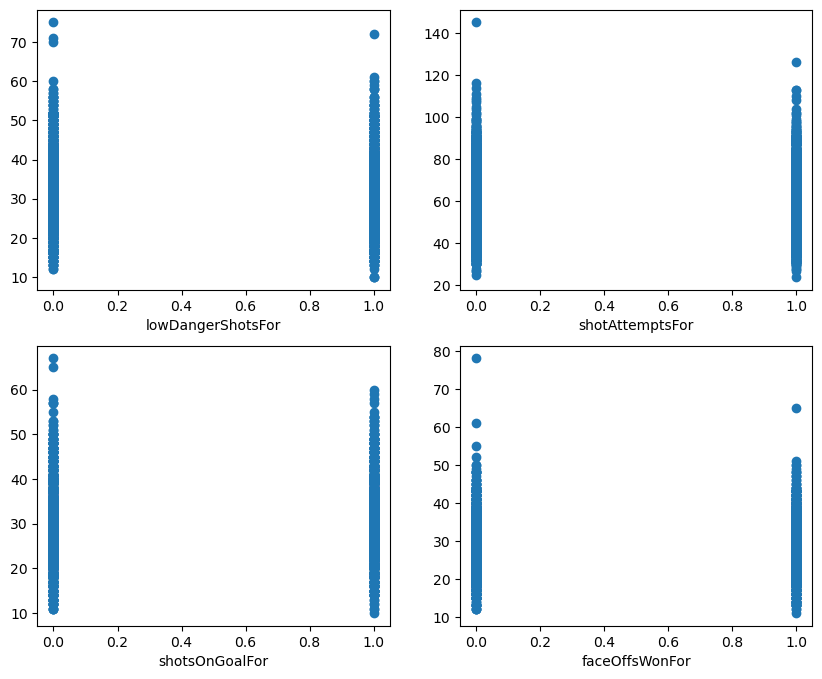

In [9]:
# Scatter plots
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
ax[0,0].scatter(df_all['win'], df_all['lowDangerShotsFor'])
ax[0,1].scatter(df_all['win'], df_all['shotAttemptsFor'])
ax[1,0].scatter(df_all['win'], df_all['shotsOnGoalFor'])
ax[1,1].scatter(df_all['win'], df_all['faceOffsWonFor'])

ax[0,0].set_xlabel('lowDangerShotsFor')
ax[0,1].set_xlabel('shotAttemptsFor')
ax[1,0].set_xlabel('shotsOnGoalFor')
ax[1,1].set_xlabel('faceOffsWonFor')

Since the dataset utilizes exact values for each game, we calculate the average of the (important) features for the model to use for predictions, as we wouldn't have the actual values before the match we would want to predict. 
We also split each feature up into different windows so the model can learn whether more recent games are important, or overall stats:
- average of last 3 games
- average of last 5 games
- average of last 10 games
- average for all games in the season

In [10]:
# Sort by team and date first
df_avg = df_all.sort_values(['playerTeam', 'gameDate']).reset_index(drop=True)

# Average for a team's last 3 games average
df_avg['xGoalsFor_last3'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last3'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=3).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last3'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=3).mean().reset_index(0, drop=True)

# For a team's last 5 games average
df_avg['xGoalsFor_last5'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last5'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=5).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last5'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=5).mean().reset_index(0, drop=True)

# For a team's last 10 games average
df_avg['xGoalsFor_last10'] = df_avg.groupby('playerTeam')['xGoalsFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['shotsOnGoalFor_last10'] = df_avg.groupby('playerTeam')['shotsOnGoalFor'].rolling(window=10).mean().reset_index(0, drop=True)
df_avg['xGoalsAgainst_last10'] = df_avg.groupby('playerTeam')['xGoalsAgainst'].rolling(window=10).mean().reset_index(0, drop=True)

# For season so far
df_avg['xGoalsFor_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xshotsOnGoalFor_season'] = df_avg.groupby(['playerTeam', 'season'])['shotsOnGoalFor'].transform(lambda x: x.expanding().mean().values)
df_avg['xGoalsAgainst_season'] = df_avg.groupby(['playerTeam', 'season'])['xGoalsAgainst'].transform(lambda x: x.expanding().mean().values)

df_avg.head(10)

,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,shotAttempt_diff,faceOff_diff,xGoalsFor_last3,shotsOnGoalFor_last3,xGoalsAgainst_last3,xGoalsFor_last5,shotsOnGoalFor_last5,xGoalsAgainst_last5,xGoalsFor_last10,shotsOnGoalFor_last10,xGoalsAgainst_last10,xGoalsFor_season,xshotsOnGoalFor_season,xGoalsAgainst_season
0,ANA,2022,ANA,2022020009,ANA,SEA,HOME,20221012,Team Level,all,0.3188,0.3607,0.3404,3655.0,22.921,2.356,1.766,5.093,0.704,13.068,9.014,2.298,2.259,2.203,27.0,5.0,12.0,44.0,5.0,1.0,0.0,6.0,1.0,9.0,10.0,22.0,27.0,6.0,15.0,32.0,15.0,6.0,10.0,18.0,12.0,2.0,0.513,1.347,0.496,1.0,3.0,1.0,41.735,32.0,30.740,4.0,0.397,0.148,0.148,2.605,2.505,2.456,44.260,5.035,3.188,9.554,1.398,25.612,17.213,4.880,5.265,5.100,48.0,14.0,16.0,78.0,4.0,5.0,1.0,7.0,2.0,22.0,22.0,44.0,58.0,4.0,11.0,24.0,22.0,4.0,6.0,44.0,13.0,5.0,0.992,1.802,2.241,0.0,1.0,3.0,82.147,62.0,65.426,2.0,0.710,0.974,0.974,4.771,4.975,4.912,0,1,-21.0,2.0,-34.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.356000,27.000000,5.035000
1,ANA,2022,ANA,2022020032,ANA,NYI,AWAY,20221015,Team Level,all,0.3821,0.4560,0.4066,3600.0,26.321,2.389,1.956,6.403,0.942,14.901,10.409,2.280,2.357,2.250,23.0,14.0,20.0,57.0,1.0,5.0,0.0,7.0,1.0,16.0,7.0,22.0,36.0,5.0,10.0,28.0,14.0,2.0,9.0,26.0,10.0,1.0,0.773,1.275,0.341,0.0,1.0,0.0,54.505,37.0,36.172,5.0,0.441,0.955,0.955,1.874,1.852,1.808,36.594,3.863,2.766,8.732,1.316,22.821,14.502,3.692,3.869,3.697,38.0,16.0,14.0,68.0,7.0,4.0,1.0,9.0,2.0,13.0,19.0,31.0,47.0,5.0,10.0,37.0,18.0,6.0,19.0,40.0,11.0,3.0,1.383,1.408,1.072,5.0,0.0,2.0,71.918,54.0,55.413,8.0,0.594,1.063,1.063,3.394,3.425,3.351,0,0,-15.0,0.0,-11.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.372500,25.000000,4.449000
2,ANA,2022,ANA,2022020039,ANA,NYR,AWAY,202

Now that the features have been engineered, we can begin training our model. The workflow will go like this:
1) Split the data into 80/20, and leave the 20% for final testing after cross validation
2) Use a time-series cross validation approach to ensure that the model is not using information from the future. This prevents data leakage
3) Retrain the best model if needed
4) Evaluate model

In [11]:
X = df_avg[['xGoalsFor_last3', 'shotsOnGoalFor_last3', 'xGoalsAgainst_last3',
     'xGoalsFor_last5', 'shotsOnGoalFor_last5', 'xGoalsAgainst_last5',
     'xGoalsFor_last10', 'shotsOnGoalFor_last10', 'xGoalsAgainst_last10',
     'xGoalsFor_season', 'xshotsOnGoalFor_season', 'xGoalsAgainst_season']]
y = df_avg[['win']]

# Split the data into 80/20, preserving chronological order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# Some rows have NaN values, drop them
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(6654, 12)
(6654,)
(1671, 12)
(1671,)


In [12]:
# copy df_recent so we don't mess it up
df_sit = df_recent.copy()

# One row per (game, team, home/away), columns = stats for each situation
df_pivot = df_sit.pivot_table(
    index=["gameId", "playerTeam", "home_or_away"],
    columns="situation",
    aggfunc="first"
)

# Flatten the MultiIndex columns: (stat, situation) -> "stat_situation"
df_pivot.columns = [f"{stat}_{sit}" for stat, sit in df_pivot.columns]
df_pivot = df_pivot.reset_index()

print("Pivoted shape:", df_pivot.shape)
df_pivot.head()

Pivoted shape: (9206, 543)


,gameId,playerTeam,home_or_away,blockedShotAttemptsAgainst_4on5,blockedShotAttemptsAgainst_5on4,blockedShotAttemptsAgainst_5on5,blockedShotAttemptsAgainst_all,blockedShotAttemptsAgainst_other,blockedShotAttemptsFor_4on5,blockedShotAttemptsFor_5on4,blockedShotAttemptsFor_5on5,blockedShotAttemptsFor_all,blockedShotAttemptsFor_other,corsiPercentage_4on5,corsiPercentage_5on4,corsiPercentage_5on5,corsiPercentage_all,corsiPercentage_other,dZoneGiveawaysAgainst_4on5,dZoneGiveawaysAgainst_5on4,dZoneGiveawaysAgainst_5on5,dZoneGiveawaysAgainst_all,dZoneGiveawaysAgainst_other,dZoneGiveawaysFor_4on5,dZoneGiveawaysFor_5on4,dZoneGiveawaysFor_5on5,dZoneGiveawaysFor_all,dZoneGiveawaysFor_other,faceOffsWonAgainst_4on5,faceOffsWonAgainst_5on4,faceOffsWonAgainst_5on5,faceOffsWonAgainst_all,faceOffsWonAgainst_other,faceOffsWonFor_4on5,faceOffsWonFor_5on4,faceOffsWonFor_5on5,faceOffsWonFor_all,faceOffsWonFor_other,fenwickPercentage_4on5,fenwickPercentage_5on4,fenwickPercentage_5on5,fenwickPercentage_all,fenwickPercentage_other,flurryAdjustedxGoalsAgainst_4on5,flurryAdjustedxGoalsAgainst_5on4,flurryAdjustedxGoalsAgainst_5on5,flurryAdjustedxGoalsAgainst_all,flurryAdjustedxGoalsAgainst_other,flurryAdjustedxGoalsFor_4on5,flurryAdjustedxGoalsFor_5on4,flurryAdjustedxGoalsFor_5on5,flurryAdjustedxGoalsFor_all,flurryAdjustedxGoalsFor_other,flurryScoreVenueAdjustedxGoalsAgainst_4on5,flurryScoreVenueAdjustedxGoalsAgainst_5on4,flurryScoreVenueAdjustedxGoalsAgainst_5on5,flurryScoreVenueAdjustedxGoalsAgainst_all,flurryScoreVenueAdjustedxGoalsAgainst_other,flurryScoreVenueAdjustedxGoalsFor_4on5,flurryScoreVenueAdjustedxGoalsFor_5on4,flurryScoreVenueAdjustedxGoalsFor_5on5,flurryScoreVenueAdjustedxGoalsFor_all,flurryScoreVenueAdjustedxGoalsFor_other,freezeAgainst_4on5,freezeAgainst_5on4,freezeAgainst_5on5,freezeAgainst_all,freezeAgainst_other,freezeFor_4on5,freezeFor_5on4,freezeFor_5on5,freezeFor_all,freezeFor_other,gameDate_4on5,gameDate_5on4,gameDate_5on5,gameDate_all,gameDate_other,giveawaysAgainst_4on5,giveawaysAgainst_5on4,giveawaysAgainst_5on5,giveawaysAgainst_all,giveawaysAgainst_other,giveawaysFor_4on5,giveawaysFor_5on4,giveawaysFor_5on5,giveawaysFor_all,giveawaysFor_other,goalsAgainst_4on5,goalsAgainst_5on4,goalsAgainst_5on5,goalsAgainst_all,goalsAgainst_other,goalsFor_4on5,goalsFor_5on4,goalsFor_5on5,goalsFor_all,goalsFor_other,highDangerGoalsAgainst_4on5,highDangerGoalsAgainst_5on4,highDangerGoalsAgainst_5on5,highDangerGoalsAgainst_all,highDangerGoalsAgainst_other,highDangerGoalsFor_4on5,highDangerGoalsFor_5on4,highDangerGoalsFor_5on5,highDangerGoalsFor_all,highDangerGoalsFor_other,highDangerShotsAgainst_4on5,highDangerShotsAgainst_5on4,highDangerShotsAgainst_5on5,highDangerShotsAgainst_all,highDangerShotsAgainst_other,highDangerShotsFor_4on5,highDangerShotsFor_5on4,highDangerShotsFor_5on5,highDangerShotsFor_all,highDangerShotsFor_other,highDangerxGoalsAgainst_4on5,highDangerxGoalsAgainst_5on4,highDangerxGoalsAgainst_5on5,highDangerxGoalsAgainst_all,highDangerxGoalsAgainst_other,highDangerxGoalsFor_4on5,highDangerxGoalsFor_5on4,highDangerxGoalsFor_5on5,highDangerxGoalsFor_all,highDangerxGoalsFor_other,hitsAgainst_4on5,hitsAgainst_5on4,hitsAgainst_5on5,hitsAgainst_all,hitsAgainst_other,hitsFor_4on5,hitsFor_5on4,hitsFor_5on5,hitsFor_all,hitsFor_other,iceTime_4on5,iceTime_5on4,iceTime_5on5,iceTime_all,iceTime_other,lowDangerGoalsAgainst_4on5,lowDangerGoalsAgainst_5on4,lowDangerGoalsAgainst_5on5,lowDangerGoalsAgainst_all,lowDangerGoalsAgainst_other,lowDangerGoalsFor_4on5,lowDangerGoalsFor_5on4,lowDangerGoalsFor_5on5,lowDangerGoalsFor_all,lowDangerGoalsFor_other,lowDangerShotsAgainst_4on5,lowDangerShotsAgainst_5on4,lowDangerShotsAgainst_5on5,lowDangerShotsAgainst_all,lowDangerShotsAgainst_other,lowDangerShotsFor_4on5,lowDangerShotsFor_5on4,lowDangerShotsFor_5on5,lowDangerShotsFor_all,lowDangerShotsFor_other,lowDangerxGoalsAgainst_4on5,lowDangerxGoalsAgainst_5on4,lowDangerxGoalsAgainst_5on5,lowDangerxGoalsAgainst_all,lowDangerxGoalsAgainst_other,lowDangerxGoa

In [13]:
# Clean core missing values (need at least all & 5on5 stats)

core_cols = [
    "xGoalsFor_all",
    "xGoalsAgainst_all",
    "xGoalsFor_5on5",
    "xGoalsAgainst_5on5",
]

df_pivot = df_pivot.dropna(subset=core_cols).copy()
print("After dropping rows missing core stats:", df_pivot.shape)

# Quick peek at some key columns
df_pivot[[
    "gameId", "playerTeam", "home_or_away",
    "xGoalsFor_all", "xGoalsAgainst_all",
    "xGoalsFor_5on5", "xGoalsAgainst_5on5"
]].head()

After dropping rows missing core stats: (9206, 543)


,gameId,playerTeam,home_or_away,xGoalsFor_all,xGoalsAgainst_all,xGoalsFor_5on5,xGoalsAgainst_5on5
0,2022020001,NSH,HOME,5.297,2.393,3.110,2.210
1,2022020001,SJS,AWAY,2.393,5.297,2.210,3.110
2,2022020002,NSH,AWAY,1.403,3.441,1.239,1.732
3,2022020002,SJS,HOME,3.441,1.403,1.732,1.239
4,2022020003,NYR,HOME,5.589,2.754,2.112,1.279


In [14]:
# Even-strength (5v5) expected goal differential
df_pivot["ES_xG_diff"] = df_pivot["xGoalsFor_5on5"] - df_pivot["xGoalsAgainst_5on5"]

# Power-play efficiency (5on4)
df_pivot["PP_xG_for"] = df_pivot.get("xGoalsFor_5on4", 0)
df_pivot["PP_shots_for"] = df_pivot.get("shotsOnGoalFor_5on4", 0)
df_pivot["PP_efficiency"] = df_pivot["PP_xG_for"] / (df_pivot["PP_shots_for"] + 1)

# Penalty-kill efficiency (4on5) – lower is better
df_pivot["PK_xG_allowed"] = df_pivot.get("xGoalsAgainst_4on5", 0)
df_pivot["PK_shots_allowed"] = df_pivot.get("shotsOnGoalAgainst_4on5", 0)
df_pivot["PK_efficiency"] = df_pivot["PK_xG_allowed"] / (df_pivot["PK_shots_allowed"] + 1)

# Discipline from ALL situation
df_pivot["penalty_diff"] = df_pivot["penaltiesFor_all"] - df_pivot["penaltiesAgainst_all"]

df_pivot[[
    "ES_xG_diff",
    "PP_efficiency",
    "PK_efficiency",
    "penalty_diff"
]].head()


,ES_xG_diff,PP_efficiency,PK_efficiency,penalty_diff
0,0.900,0.155444,0.013333,0.0
1,-0.900,0.013333,0.155444,0.0
2,-0.493,0.011333,0.141444,1.0
3,0.493,0.141444,0.011333,-1.0
4,0.833,0.148667,0.012571,2.0


In [15]:
# Pre-game pipeline: build team-game table from df_recent

# Start from team-level rows only
df_pre_raw = df_recent[df_recent["position"] == "Team Level"].copy()

# Get win + date info from ALL-situation rows (one per team-game)
df_pre_win = df_pre_raw[df_pre_raw["situation"] == "all"][[
    "gameId", "playerTeam", "home_or_away", "gameDate", "win"
]].copy()

# Pivot situations (all, 5on5, 5on4, 4on5, other) into columns
df_pre_pivot = df_pre_raw.pivot_table(
    index=["gameId", "playerTeam", "home_or_away"],
    columns="situation",
    aggfunc="first"
)

# Flatten multi-index columns: (stat, situation) -> "stat_situation"
df_pre_pivot.columns = [f"{stat}_{sit}" for stat, sit in df_pre_pivot.columns]
df_pre_pivot = df_pre_pivot.reset_index()

# Merge win + date back in
df_teamgames = df_pre_pivot.merge(
    df_pre_win,
    on=["gameId", "playerTeam", "home_or_away"],
    how="left"
)

print("Team-game table shape:", df_teamgames.shape)
df_teamgames.head()


Team-game table shape: (9206, 545)


,gameId,playerTeam,home_or_away,blockedShotAttemptsAgainst_4on5,blockedShotAttemptsAgainst_5on4,blockedShotAttemptsAgainst_5on5,blockedShotAttemptsAgainst_all,blockedShotAttemptsAgainst_other,blockedShotAttemptsFor_4on5,blockedShotAttemptsFor_5on4,blockedShotAttemptsFor_5on5,blockedShotAttemptsFor_all,blockedShotAttemptsFor_other,corsiPercentage_4on5,corsiPercentage_5on4,corsiPercentage_5on5,corsiPercentage_all,corsiPercentage_other,dZoneGiveawaysAgainst_4on5,dZoneGiveawaysAgainst_5on4,dZoneGiveawaysAgainst_5on5,dZoneGiveawaysAgainst_all,dZoneGiveawaysAgainst_other,dZoneGiveawaysFor_4on5,dZoneGiveawaysFor_5on4,dZoneGiveawaysFor_5on5,dZoneGiveawaysFor_all,dZoneGiveawaysFor_other,faceOffsWonAgainst_4on5,faceOffsWonAgainst_5on4,faceOffsWonAgainst_5on5,faceOffsWonAgainst_all,faceOffsWonAgainst_other,faceOffsWonFor_4on5,faceOffsWonFor_5on4,faceOffsWonFor_5on5,faceOffsWonFor_all,faceOffsWonFor_other,fenwickPercentage_4on5,fenwickPercentage_5on4,fenwickPercentage_5on5,fenwickPercentage_all,fenwickPercentage_other,flurryAdjustedxGoalsAgainst_4on5,flurryAdjustedxGoalsAgainst_5on4,flurryAdjustedxGoalsAgainst_5on5,flurryAdjustedxGoalsAgainst_all,flurryAdjustedxGoalsAgainst_other,flurryAdjustedxGoalsFor_4on5,flurryAdjustedxGoalsFor_5on4,flurryAdjustedxGoalsFor_5on5,flurryAdjustedxGoalsFor_all,flurryAdjustedxGoalsFor_other,flurryScoreVenueAdjustedxGoalsAgainst_4on5,flurryScoreVenueAdjustedxGoalsAgainst_5on4,flurryScoreVenueAdjustedxGoalsAgainst_5on5,flurryScoreVenueAdjustedxGoalsAgainst_all,flurryScoreVenueAdjustedxGoalsAgainst_other,flurryScoreVenueAdjustedxGoalsFor_4on5,flurryScoreVenueAdjustedxGoalsFor_5on4,flurryScoreVenueAdjustedxGoalsFor_5on5,flurryScoreVenueAdjustedxGoalsFor_all,flurryScoreVenueAdjustedxGoalsFor_other,freezeAgainst_4on5,freezeAgainst_5on4,freezeAgainst_5on5,freezeAgainst_all,freezeAgainst_other,freezeFor_4on5,freezeFor_5on4,freezeFor_5on5,freezeFor_all,freezeFor_other,gameDate_4on5,gameDate_5on4,gameDate_5on5,gameDate_all,gameDate_other,giveawaysAgainst_4on5,giveawaysAgainst_5on4,giveawaysAgainst_5on5,giveawaysAgainst_all,giveawaysAgainst_other,giveawaysFor_4on5,giveawaysFor_5on4,giveawaysFor_5on5,giveawaysFor_all,giveawaysFor_other,goalsAgainst_4on5,goalsAgainst_5on4,goalsAgainst_5on5,goalsAgainst_all,goalsAgainst_other,goalsFor_4on5,goalsFor_5on4,goalsFor_5on5,goalsFor_all,goalsFor_other,highDangerGoalsAgainst_4on5,highDangerGoalsAgainst_5on4,highDangerGoalsAgainst_5on5,highDangerGoalsAgainst_all,highDangerGoalsAgainst_other,highDangerGoalsFor_4on5,highDangerGoalsFor_5on4,highDangerGoalsFor_5on5,highDangerGoalsFor_all,highDangerGoalsFor_other,highDangerShotsAgainst_4on5,highDangerShotsAgainst_5on4,highDangerShotsAgainst_5on5,highDangerShotsAgainst_all,highDangerShotsAgainst_other,highDangerShotsFor_4on5,highDangerShotsFor_5on4,highDangerShotsFor_5on5,highDangerShotsFor_all,highDangerShotsFor_other,highDangerxGoalsAgainst_4on5,highDangerxGoalsAgainst_5on4,highDangerxGoalsAgainst_5on5,highDangerxGoalsAgainst_all,highDangerxGoalsAgainst_other,highDangerxGoalsFor_4on5,highDangerxGoalsFor_5on4,highDangerxGoalsFor_5on5,highDangerxGoalsFor_all,highDangerxGoalsFor_other,hitsAgainst_4on5,hitsAgainst_5on4,hitsAgainst_5on5,hitsAgainst_all,hitsAgainst_other,hitsFor_4on5,hitsFor_5on4,hitsFor_5on5,hitsFor_all,hitsFor_other,iceTime_4on5,iceTime_5on4,iceTime_5on5,iceTime_all,iceTime_other,lowDangerGoalsAgainst_4on5,lowDangerGoalsAgainst_5on4,lowDangerGoalsAgainst_5on5,lowDangerGoalsAgainst_all,lowDangerGoalsAgainst_other,lowDangerGoalsFor_4on5,lowDangerGoalsFor_5on4,lowDangerGoalsFor_5on5,lowDangerGoalsFor_all,lowDangerGoalsFor_other,lowDangerShotsAgainst_4on5,lowDangerShotsAgainst_5on4,lowDangerShotsAgainst_5on5,lowDangerShotsAgainst_all,lowDangerShotsAgainst_other,lowDangerShotsFor_4on5,lowDangerShotsFor_5on4,lowDangerShotsFor_5on5,lowDangerShotsFor_all,lowDangerShotsFor_other,lowDangerxGoalsAgainst_4on5,lowDangerxGoalsAgainst_5on4,lowDangerxGoalsAgainst_5on5,lowDangerxGoalsAgainst_all,lowDangerxGoalsAgainst_other,lowDangerxGoa

In [16]:
# Per-game composite stats (still in-game; will roll them next)

df_pg = df_teamgames.copy()

# Even-strength (5v5) expected goal differential
df_pg["ES_xG_diff_5v5"] = df_pg["xGoalsFor_5on5"] - df_pg["xGoalsAgainst_5on5"]

# Power-play xG rate (5on4)
df_pg["PP_xG_rate"] = df_pg["xGoalsFor_5on4"] / (df_pg["shotsOnGoalFor_5on4"] + 1)

# Penalty-kill xG allowed rate (4on5) – lower is better
df_pg["PK_xG_allowed_rate"] = df_pg["xGoalsAgainst_4on5"] / (df_pg["shotsOnGoalAgainst_4on5"] + 1)

# Discipline (all situations)
df_pg["penalty_diff_all"] = df_pg["penaltiesFor_all"] - df_pg["penaltiesAgainst_all"]

# Home indicator
df_pg["is_home"] = (df_pg["home_or_away"] == "HOME").astype(int)

df_pg[[
    "playerTeam", "gameDate", "ES_xG_diff_5v5",
    "PP_xG_rate", "PK_xG_allowed_rate", "penalty_diff_all", "is_home", "win"
]].head()


,playerTeam,gameDate,ES_xG_diff_5v5,PP_xG_rate,PK_xG_allowed_rate,penalty_diff_all,is_home,win
0,NSH,20221007,0.900,0.155444,0.013333,0.0,1,1
1,SJS,20221007,-0.900,0.013333,0.155444,0.0,0,0
2,NSH,20221008,-0.493,0.011333,0.141444,1.0,0,1
3,SJS,20221008,0.493,0.141444,0.011333,-1.0,1,0
4,NYR,20221011,0.833,0.148667,0.012571,2.0,1,1


In [17]:
# Ensure chronological order within each team
df_pg = df_pg.sort_values(["playerTeam", "gameDate"]).copy()
df_pg["gameDate_dt"] = pd.to_datetime(df_pg["gameDate"], format="%Y%m%d")

g = df_pg.groupby("playerTeam", group_keys=False)

# Rolling even-strength xG differential
df_pg["ES_xG_diff_last3"] = g["ES_xG_diff_5v5"].apply(
    lambda s: s.shift(1).rolling(3).mean()
)
df_pg["ES_xG_diff_last5"] = g["ES_xG_diff_5v5"].apply(
    lambda s: s.shift(1).rolling(5).mean()
)

# Rolling PP and PK metrics
df_pg["PP_xG_rate_last3"] = g["PP_xG_rate"].apply(
    lambda s: s.shift(1).rolling(3).mean()
)
df_pg["PK_xG_allowed_rate_last3"] = g["PK_xG_allowed_rate"].apply(
    lambda s: s.shift(1).rolling(3).mean()
)

# Rolling discipline (over last 5 games)
df_pg["penalty_diff_all_last5"] = g["penalty_diff_all"].apply(
    lambda s: s.shift(1).rolling(5).mean()
)

# Rolling win% (form / momentum)
for window in [5, 10]:
    df_pg[f"win_rate_last{window}"] = g["win"].apply(
        lambda s: s.shift(1).rolling(window).mean()
    )

# Rest days (time since last game for that team)
df_pg["days_since_last_game"] = g["gameDate_dt"].apply(
    lambda s: s.diff().dt.days
)

df_pg[[
    "playerTeam", "gameDate", "ES_xG_diff_last3", "ES_xG_diff_last5",
    "PP_xG_rate_last3", "PK_xG_allowed_rate_last3",
    "penalty_diff_all_last5", "win_rate_last5", "win_rate_last10",
    "days_since_last_game", "is_home", "win"
]].head(12)

,playerTeam,gameDate,ES_xG_diff_last3,ES_xG_diff_last5,PP_xG_rate_last3,PK_xG_allowed_rate_last3,penalty_diff_all_last5,win_rate_last5,win_rate_last10,days_since_last_game,is_home,win
16,ANA,20221012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
62,ANA,20221015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0,0
76,ANA,20221017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0,0
94,ANA,20221018,-0.992667,NaN,0.046270,0.124365,NaN,NaN,NaN,1.0,0,0
116,ANA,20221020,-1.073667,NaN,0.010278,0.118274,NaN,NaN,NaN,2.0,0,0
174,ANA,20221023,-1.241000,-1.1394,0.012028,0.114783,1.0,0.2,NaN,3.0,0,0
218,ANA,20221026,-0.774000,-0.7510,0.012583,0.119583,0.6,0.0,NaN,3.0,1,0
240,ANA,20221028,-0.494667,-0.8552,0.036306,0.107717,0.8,0.0,NaN,2.0,0,0
282,ANA,20221030,-0.321333,-0.7366,0.034622,0.098800,0.2,0.0,NaN,2.0,1,1
314,ANA,20221101,-0.564667,-0.4456,0.054761,0.104400,0.6,0.2,NaN,2.0,0,0


In [18]:
# Final pre-game feature matrix and target

pre_features = [
    "ES_xG_diff_last3",
    "ES_xG_diff_last5",
    "PP_xG_rate_last3",
    "PK_xG_allowed_rate_last3",
    "penalty_diff_all_last5",
    "win_rate_last5",
    "win_rate_last10",
    "days_since_last_game",
    "is_home",
]

# Drop rows that don't have enough history for all rolling features
df_pre_model = df_pg.dropna(subset=pre_features).copy()

# Sort by date globally so train/test is chronological
df_pre_model = df_pre_model.sort_values("gameDate_dt")

X_pre = df_pre_model[pre_features]
y_pre = df_pre_model["win"].astype(int)

print("Pre-game dataset shape:", X_pre.shape)
X_pre.head()

Pre-game dataset shape: (8876, 9)


,ES_xG_diff_last3,ES_xG_diff_last5,PP_xG_rate_last3,PK_xG_allowed_rate_last3,penalty_diff_all_last5,win_rate_last5,win_rate_last10,days_since_last_game,is_home
256,0.175000,-0.1242,0.066278,0.086694,0.6,0.6,0.3,2.0,1
290,0.987000,0.6214,0.090715,0.091361,0.0,0.4,0.4,2.0,0
315,-0.476333,-0.3640,0.111111,0.052278,0.0,0.4,0.3,3.0,1
299,-0.004667,-0.4798,0.052821,0.140690,0.6,0.6,0.5,1.0,1
309,0.745000,0.8010,0.100500,0.153167,-0.8,0.6,0.4,3.0,0


In [19]:
# Chronological train/test split and baseline models

# 80% earliest games for training, 20% latest for testing
cut = int(len(X_pre) * 0.8)
X_pre_train, X_pre_test = X_pre.iloc[:cut], X_pre.iloc[cut:]
y_pre_train, y_pre_test = y_pre.iloc[:cut], y_pre.iloc[cut:]

# Logistic Regression
log_pre = LogisticRegression(max_iter=1000)
log_pre.fit(X_pre_train, y_pre_train)
y_pre_pred_log = log_pre.predict(X_pre_test)
acc_pre_log = accuracy_score(y_pre_test, y_pre_pred_log)

# Random Forest
rf_pre = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_pre.fit(X_pre_train, y_pre_train)
y_pre_pred_rf = rf_pre.predict(X_pre_test)
acc_pre_rf = accuracy_score(y_pre_test, y_pre_pred_rf)

print("Pre-game Model Accuracy (chronological split)")
print(f"Logistic Regression: {acc_pre_log:.4f}")
print(f"Random Forest      : {acc_pre_rf:.4f}")

Pre-game Model Accuracy (chronological split)
Logistic Regression: 0.5659
Random Forest      : 0.5349


Using only pre-game rolling features (previous xG, PP/PK strength, discipline, win rates, and rest days), the models achieved realistic forecasting performance. Logistic Regression reached 56.6% accuracy, while Random Forest reached 53.5% on a chronological test set. These results align with the expected ~60% theoretical ceiling for true NHL pre-game prediction, showing that the model is reliably capturing meaningful pre-game patterns without using any in-game information.

In [20]:
# Attach opponent rolling features to each team-game row
df_pre = df_pre_model.copy()

# Rename columns for self-merge clarity
team_cols = {col: f"team_{col}" for col in df_pre.columns}
opp_cols  = {col: f"opp_{col}"  for col in df_pre.columns}

df_team = df_pre.rename(columns=team_cols)
df_opp  = df_pre.rename(columns=opp_cols)

# Merge team row with opponent row on gameId (same game)
df_matchups = pd.merge(
    df_team,
    df_opp,
    left_on=["team_gameId"],
    right_on=["opp_gameId"],
    how="inner"
)

# Filter out self-joins (team != opponent)
df_matchups = df_matchups[
    df_matchups["team_playerTeam"] != df_matchups["opp_playerTeam"]
].copy()

print("Matchup table shape:", df_matchups.shape)
df_matchups.head()

Matchup table shape: (8848, 1118)


,team_gameId,team_playerTeam,team_home_or_away,team_blockedShotAttemptsAgainst_4on5,team_blockedShotAttemptsAgainst_5on4,team_blockedShotAttemptsAgainst_5on5,team_blockedShotAttemptsAgainst_all,team_blockedShotAttemptsAgainst_other,team_blockedShotAttemptsFor_4on5,team_blockedShotAttemptsFor_5on4,team_blockedShotAttemptsFor_5on5,team_blockedShotAttemptsFor_all,team_blockedShotAttemptsFor_other,team_corsiPercentage_4on5,team_corsiPercentage_5on4,team_corsiPercentage_5on5,team_corsiPercentage_all,team_corsiPercentage_other,team_dZoneGiveawaysAgainst_4on5,team_dZoneGiveawaysAgainst_5on4,team_dZoneGiveawaysAgainst_5on5,team_dZoneGiveawaysAgainst_all,team_dZoneGiveawaysAgainst_other,team_dZoneGiveawaysFor_4on5,team_dZoneGiveawaysFor_5on4,team_dZoneGiveawaysFor_5on5,team_dZoneGiveawaysFor_all,team_dZoneGiveawaysFor_other,team_faceOffsWonAgainst_4on5,team_faceOffsWonAgainst_5on4,team_faceOffsWonAgainst_5on5,team_faceOffsWonAgainst_all,team_faceOffsWonAgainst_other,team_faceOffsWonFor_4on5,team_faceOffsWonFor_5on4,team_faceOffsWonFor_5on5,team_faceOffsWonFor_all,team_faceOffsWonFor_other,team_fenwickPercentage_4on5,team_fenwickPercentage_5on4,team_fenwickPercentage_5on5,team_fenwickPercentage_all,team_fenwickPercentage_other,team_flurryAdjustedxGoalsAgainst_4on5,team_flurryAdjustedxGoalsAgainst_5on4,team_flurryAdjustedxGoalsAgainst_5on5,team_flurryAdjustedxGoalsAgainst_all,team_flurryAdjustedxGoalsAgainst_other,team_flurryAdjustedxGoalsFor_4on5,team_flurryAdjustedxGoalsFor_5on4,team_flurryAdjustedxGoalsFor_5on5,team_flurryAdjustedxGoalsFor_all,team_flurryAdjustedxGoalsFor_other,team_flurryScoreVenueAdjustedxGoalsAgainst_4on5,team_flurryScoreVenueAdjustedxGoalsAgainst_5on4,team_flurryScoreVenueAdjustedxGoalsAgainst_5on5,team_flurryScoreVenueAdjustedxGoalsAgainst_all,team_flurryScoreVenueAdjustedxGoalsAgainst_other,team_flurryScoreVenueAdjustedxGoalsFor_4on5,team_flurryScoreVenueAdjustedxGoalsFor_5on4,team_flurryScoreVenueAdjustedxGoalsFor_5on5,team_flurryScoreVenueAdjustedxGoalsFor_all,team_flurryScoreVenueAdjustedxGoalsFor_other,team_freezeAgainst_4on5,team_freezeAgainst_5on4,team_freezeAgainst_5on5,team_freezeAgainst_all,team_freezeAgainst_other,team_freezeFor_4on5,team_freezeFor_5on4,team_freezeFor_5on5,team_freezeFor_all,team_freezeFor_other,team_gameDate_4on5,team_gameDate_5on4,team_gameDate_5on5,team_gameDate_all,team_gameDate_other,team_giveawaysAgainst_4on5,team_giveawaysAgainst_5on4,team_giveawaysAgainst_5on5,team_giveawaysAgainst_all,team_giveawaysAgainst_other,team_giveawaysFor_4on5,team_giveawaysFor_5on4,team_giveawaysFor_5on5,team_giveawaysFor_all,team_giveawaysFor_other,team_goalsAgainst_4on5,team_goalsAgainst_5on4,team_goalsAgainst_5on5,team_goalsAgainst_all,team_goalsAgainst_other,team_goalsFor_4on5,team_goalsFor_5on4,team_goalsFor_5on5,team_goalsFor_all,team_goalsFor_other,team_highDangerGoalsAgainst_4on5,team_highDangerGoalsAgainst_5on4,team_highDangerGoalsAgainst_5on5,team_highDangerGoalsAgainst_all,team_highDangerGoalsAgainst_other,team_highDangerGoalsFor_4on5,team_highDangerGoalsFor_5on4,team_highDangerGoalsFor_5on5,team_highDangerGoalsFor_all,team_highDangerGoalsFor_other,team_highDangerShotsAgainst_4on5,team_highDangerShotsAgainst_5on4,team_highDangerShotsAgainst_5on5,team_highDangerShotsAgainst_all,team_highDangerShotsAgainst_other,team_highDangerShotsFor_4on5,team_highDangerShotsFor_5on4,team_highDangerShotsFor_5on5,team_highDangerShotsFor_all,team_highDangerShotsFor_other,team_highDangerxGoalsAgainst_4on5,team_highDangerxGoalsAgainst_5on4,team_highDangerxGoalsAgainst_5on5,team_highDangerxGoalsAgainst_all,team_highDangerxGoalsAgainst_other,team_highDangerxGoalsFor_4on5,team_highDangerxGoalsFor_5on4,team_highDangerxGoalsFor_5on5,team_highDangerxGoalsFor_all,team_highDangerxGoalsFor_other,team_hitsAgainst_4on5,team_hitsAgainst_5on4,team_hitsAgainst_5on5,team_hitsAgainst_all,team_hitsAgainst_other,team_hitsFor_4on5,team_hitsFor_5on4,team_hitsFor_5on5,team_hitsFor_all,team_hitsFor_other,team_iceTime_4on5,team_iceTi

In [21]:
# Difference features (team minus opponent)
df_matchups["ES_xG_diff3_vs_opp"] = (
    df_matchups["team_ES_xG_diff_last3"] -
    df_matchups["opp_ES_xG_diff_last3"]
)

df_matchups["PP_rate3_vs_opp"] = (
    df_matchups["team_PP_xG_rate_last3"] -
    df_matchups["opp_PP_xG_rate_last3"]
)

df_matchups["PK_rate3_vs_opp"] = (
    df_matchups["team_PK_xG_allowed_rate_last3"] -
    df_matchups["opp_PK_xG_allowed_rate_last3"]
)

df_matchups["discipline_vs_opp"] = (
    df_matchups["team_penalty_diff_all_last5"] -
    df_matchups["opp_penalty_diff_all_last5"]
)

df_matchups["win_rate5_vs_opp"] = (
    df_matchups["team_win_rate_last5"] -
    df_matchups["opp_win_rate_last5"]
)

df_matchups["rest_vs_opp"] = (
    df_matchups["team_days_since_last_game"] -
    df_matchups["opp_days_since_last_game"]
)

In [22]:
# Final matchup feature matrix
matchup_features = [
    "ES_xG_diff3_vs_opp",
    "PP_rate3_vs_opp",
    "PK_rate3_vs_opp",
    "discipline_vs_opp",
    "win_rate5_vs_opp",
    "rest_vs_opp",
    "team_is_home"  # keep home advantage indicator
]

X_matchup = df_matchups[matchup_features]
y_matchup = df_matchups["team_win"].astype(int)

print("Matchup dataset shape:", X_matchup.shape)
X_matchup.head()

Matchup dataset shape: (8848, 7)


,ES_xG_diff3_vs_opp,PP_rate3_vs_opp,PK_rate3_vs_opp,discipline_vs_opp,win_rate5_vs_opp,rest_vs_opp,team_is_home
4,-1.465333,-0.025567,0.124707,1.2,-0.2,-1.0,1
7,1.465333,0.025567,-0.124707,-1.2,0.2,1.0,0
15,-0.518667,-0.150197,-0.064511,0.6,-0.2,0.0,0
17,-1.343000,-0.066962,-0.014496,0.6,0.4,0.0,0
19,-1.059000,0.060028,0.091478,-0.6,0.0,0.0,0


In [23]:
# Chronological split
# 80% earliest games for training, 20% latest for testing
cut = int(len(X_matchup) * 0.8)
X_opp_train, X_opp_test = X_matchup.iloc[:cut], X_matchup.iloc[cut:]
y_opp_train, y_opp_test = y_matchup.iloc[:cut], y_matchup.iloc[cut:]

# Logistic Regression on opponent-adjusted features
log_match = LogisticRegression(max_iter=2000)
log_match.fit(X_opp_train, y_opp_train)

# Predict and evaluate
y_pred_log = log_match.predict(X_opp_test)
acc_log = accuracy_score(y_opp_test, y_pred_log)

print(f"Opponent-adjusted Logistic Regression Accuracy: {acc_log:.4f}")

Opponent-adjusted Logistic Regression Accuracy: 0.5774


In [24]:
# Create team-level summary statistics
team_summary = (
    df_recent
    .groupby("team")
    .agg({
        "win": "mean",                # win percentage
        "xGoalsPercentage": "mean",
        "corsiPercentage": "mean",
    })
    .reset_index()
)

# Rename columns for clarity
team_summary = team_summary.rename(columns={
    "win": "win_pct",
    "xGoalsPercentage": "xg_pct",
    "corsiPercentage": "corsi_pct"
})

print(team_summary.head())


  team   win_pct    xg_pct  corsi_pct
0  ANA  0.242804  0.438109   0.460530
1  BOS  0.357679  0.484209   0.487557
2  BUF  0.307011  0.476983   0.491537
3  CAR  0.371154  0.539923   0.549694
4  CBJ  0.245018  0.451422   0.472979


In [25]:
# Function to build matchup features for given home and away teams
def build_matchup_features(home_team, away_team, team_stats):
    h = team_stats[team_stats["team"] == home_team].iloc[0]
    a = team_stats[team_stats["team"] == away_team].iloc[0]

    features = {
        "home_win_pct": h["win_pct"],
        "away_win_pct": a["win_pct"],
        "home_xg_pct": h["xg_pct"],
        "away_xg_pct": a["xg_pct"],
        "home_corsi_pct": h["corsi_pct"],
        "away_corsi_pct": a["corsi_pct"],
        "win_pct_diff": h["win_pct"] - a["win_pct"],
        "xg_pct_diff": h["xg_pct"] - a["xg_pct"],
        "corsi_pct_diff": h["corsi_pct"] - a["corsi_pct"],
    }

    return pd.DataFrame([features])


In [26]:
# Build matchup dataset from all possible pairs
rows = []
teams = team_summary["team"].tolist()

for home in teams:
    for away in teams:
        if home == away:
            continue

        h = team_summary[team_summary["team"] == home].iloc[0]
        a = team_summary[team_summary["team"] == away].iloc[0]

        rows.append({
            "win_pct_diff": h["win_pct"] - a["win_pct"],
            "xg_pct_diff": h["xg_pct"] - a["xg_pct"],
            "corsi_pct_diff": h["corsi_pct"] - a["corsi_pct"],
            "y": 1 if h["win_pct"] > a["win_pct"] else 0   # label: home team stronger
        })

matchups = pd.DataFrame(rows)

X = matchups[["win_pct_diff", "xg_pct_diff", "corsi_pct_diff"]]
y = matchups["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression().fit(X_train, y_train)

print("Training accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))


Training accuracy: 0.9482976040353089
Test accuracy: 0.964824120603015


In [27]:
# Convert your raw logs into per-game matchup rows
games = (
    df_recent.groupby(["gameId", "team"])
    .agg({
        "xGoalsPercentage": "mean",
        "corsiPercentage": "mean",
        "win": "max", 
    })
    .reset_index()
)

# Pivot so each game has a home & away row on one line
home = games[games["team"].isin(games["team"].unique())]
away = games.copy()

matchups = home.merge(
    away,
    on="gameId",
    suffixes=("_home", "_away")
)

# Keep only true home/away pairs
matchups = matchups[matchups["team_home"] != matchups["team_away"]]

# Build real matchup features
matchups["xg_diff"] = matchups["xGoalsPercentage_home"] - matchups["xGoalsPercentage_away"]
matchups["corsi_diff"] = matchups["corsiPercentage_home"] - matchups["corsiPercentage_away"]

# Label: 1 if home team actually won the game
matchups["y"] = matchups["win_home"]

matchups = matchups[["xg_diff", "corsi_diff", "y"]]
print(matchups.head())


   xg_diff  corsi_diff  y
1  0.41184    -0.00988  1
2 -0.41184     0.00988  0
5 -0.59196    -0.33748  1
6  0.59196     0.33748  1
9  0.39528     0.14368  1


In [28]:
# Train XGBoost model on per-game matchup data
X = matchups[["xg_diff", "corsi_diff"]]
y = matchups["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define and train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)

# Train the model
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 0.752985884907709


In [29]:
# Function to build matchup features for XGBoost model
def build_matchup_xgb(home, away, team_stats):

    # Compute numeric averages ONLY
    h = (
        team_stats[team_stats["team"] == home]
        .select_dtypes(include="number")
        .mean()
    )

    # Compute numeric averages ONLY
    a = (
        team_stats[team_stats["team"] == away]
        .select_dtypes(include="number")
        .mean()
    )

    # Build EXACT features your XGBoost model was trained on
    return pd.DataFrame([{
        "xg_diff": h["xGoalsPercentage"] - a["xGoalsPercentage"],
        "corsi_diff": h["corsiPercentage"] - a["corsiPercentage"],
    }])


In [30]:
# Train XGBoost model on per-game matchup data
# Prepare data
df = df_recent.copy()

# Keep one row per game per team with the "all" situation and team-level stats
df = df[(df["position"] == "Team Level") & (df["situation"] == "all")].copy()

base_cols = [
    "xGoalsPercentage",
    "corsiPercentage",
]

# Check for needed columns
needed_cols = ["team", "gameId", "home_or_away", "win"] + base_cols
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep only needed columns to avoid dtype issues
df = df[needed_cols].copy()

# Ensure types are correct
df["win"] = df["win"].astype(int)

# Split into home and away teams
home = df[df["home_or_away"] == "HOME"].copy()
away = df[df["home_or_away"] == "AWAY"].copy()

# Rename columns to _home / _away for merge clarity
home = home.rename(columns={c: f"{c}_home" for c in base_cols + ["team", "win"]})
away = away.rename(columns={c: f"{c}_away" for c in base_cols + ["team", "win"]})

matchups = pd.merge(
    home[["gameId"] + [f"{c}_home" for c in base_cols + ["team", "win"]]],
    away[["gameId"] + [f"{c}_away" for c in base_cols + ["team", "win"]]],
    on="gameId",
    how="inner",
)

# Label: 1 if home team won
matchups["y"] = matchups["win_home"]

# Feature engineering: diffs (home - away)
def add_diff(df_, col):
    df_[f"{col}_diff"] = df_[f"{col}_home"] - df_[f"{col}_away"]

# Create diff features
for c in base_cols:
    add_diff(matchups, c)

# Final feature matrix
feature_cols = [f"{c}_diff" for c in base_cols]
X = matchups[feature_cols].copy()
y = matchups["y"].copy()

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.5,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
)
model.fit(X_train, y_train)

# Evaluate model
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))
print("Brier :", brier_score_loss(y_test, proba))

# extract season-to-date team averages for the app
if "season" in df_recent.columns:
    latest_season = df_recent["season"].max()
    df_inf = df_recent[
        (df_recent["position"] == "Team Level")
        & (df_recent["situation"] == "all")
        & (df_recent["season"] == latest_season)
    ].copy()
else:
    df_inf = df_recent[
        (df_recent["position"] == "Team Level") & (df_recent["situation"] == "all")
    ].copy()

# Keep only numeric columns for safe averages
num_cols = df_inf.select_dtypes(include="number").columns.tolist()
keep_for_summary = ["team"] + [c for c in base_cols if c in num_cols]
team_summary = df_inf[keep_for_summary].groupby("team").mean().reset_index()

# Save model bundle
bundle = {
    "model": model,
    "feature_names": feature_cols, # enforce same order during inference
    "team_summary": team_summary, # season-to-date team averages
    "base_cols": base_cols, # which raw cols were used
}

# Save to disk
with open("model.pkl", "wb") as f:
    pickle.dump(bundle, f)

# Confirmation message
print("Saved model.pkl with XGBoost + team_summary + feature_names")


Accuracy: 0.7328990228013029
ROC AUC: 0.7907512569687478
Brier : 0.18699359349050076
Saved model.pkl with XGBoost + team_summary + feature_names
